In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import TransformedTargetRegressor

In [2]:
# Read in main dataset
df = pd.read_csv("Resale flat prices based on registration date from Jan-2017 onwards.csv")
print(df.shape)
print(df.dtypes)

(224766, 11)
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object


In [3]:
# Read in RPI dataset
rpi_df = pd.read_csv("HDBResalePriceIndex1Q2009100Quarterly.csv")

In [4]:
# Convert the date to include quarter
df['month'] = pd.to_datetime(df['month'])
df['quarter'] = df['month'].dt.to_period('Q').astype(str)
df['quarter'] = df['quarter'].astype(str).str.replace('Q', '-Q')
df['quarter']

0         2017-Q1
1         2017-Q1
2         2017-Q1
3         2017-Q1
4         2017-Q1
           ...   
224761    2026-Q1
224762    2026-Q1
224763    2026-Q1
224764    2026-Q1
224765    2026-Q1
Name: quarter, Length: 224766, dtype: object

In [5]:
# Merge df with RPI file
df = df.merge(rpi_df, on='quarter', how='left')
df.rename(columns={'index': 'RPI'}, inplace=True)

### COMBINE DF

In [6]:
# Combine main dataset with location distance dataset
loc_all = pd.read_csv("loc_all.csv")
df = df.join(loc_all[["dist_to_mrt_m", "dist_to_mall_m", "dist_to_school_m", "dist_to_hawker_m", "dist_to_spf_m"]])
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9,934.249034,1027.883036,227.902618,172.410689,700.649811
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9,160.176577,869.965513,241.572335,408.448982,136.555811
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9,390.204129,1526.601124,775.445626,586.167266,1108.541396
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9,885.083182,892.872255,518.558573,244.836572,741.171455
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9,376.976459,1570.330140,781.266765,611.702356,1149.265548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224761,2026-01-01,YISHUN,EXECUTIVE,325,YISHUN CTRL,04 TO 06,146.0,Maisonette,1988,61 years 11 months,920000.0,2026-Q1,NaN,725.118656,430.940678,342.194942,552.047456,207.744596
224762,2026-01-01,YISHUN,EXECUTIVE,360,YISHUN RING RD,07 TO 09,142.0,Apartment,1988,61 years 07 months,865888.0,2026-Q1,NaN,1137.707795,741.408963,181.746058,321.472237,627.043848
224763,2026-01-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,60 years 09 months,825000.0,2026-Q1,NaN,604.959744,545.497230,233.272843,908.298823,535.649392
224764,2026-01-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,04 TO 06,146.0,Maisonette,1987,60 years 08 months,788000.0,2026-Q1,NaN,604.959744,545.497230,233.272843,908.298823,535.649392


In [7]:
# Sort the dataset by month in ascending order and then by town alphabetically
df = df.sort_values(["month", "town"])

In [8]:
# Check for missing values
df.isna().sum()

month                     0
town                      0
flat_type                 0
block                     0
street_name               0
storey_range              0
floor_area_sqm            0
flat_model                0
lease_commence_date       0
remaining_lease           0
resale_price              0
quarter                   0
RPI                    2689
dist_to_mrt_m             0
dist_to_mall_m            0
dist_to_school_m          0
dist_to_hawker_m          0
dist_to_spf_m             0
dtype: int64

In [9]:
# Since 2026 Q1 RPI has not been release, we will foward fill using the previous value which is 2025 Q4 RPI
df["RPI"] = df["RPI"].ffill()

In [10]:
df.columns

Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'quarter', 'RPI', 'dist_to_mrt_m',
       'dist_to_mall_m', 'dist_to_school_m', 'dist_to_hawker_m',
       'dist_to_spf_m'],
      dtype='object')

### Duplicate

In [14]:
# Check to see how many full row duplicates are there, e.g. 2 identical rows
full_dups = df.duplicated().sum()
print("Full row duplicates:", full_dups)

# Check for duplicates by a subset of key columns
# remaining_lease has been excluded as it doesn't make sense to have the same transaction month and year but different remaining lease for same HDB building
key_cols = [
    "month", "town", "flat_type", "block", "street_name",
    "storey_range", "floor_area_sqm", "flat_model", "lease_commence_date", "resale_price", 
]

key_dups = df.duplicated(subset=key_cols, keep="first").sum()
print("Duplicates by key columns:", key_dups)

Full row duplicates: 311
Duplicates by key columns: 395


In [17]:
full_dup_rows = df[df.duplicated(keep=False)]
full_dup_rows.sort_values(df.columns.tolist()).head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m
224,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0,2017-Q1,133.9,559.546902,654.171942,166.821957,436.560525,394.739264
243,2017-01-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0,2017-Q1,133.9,559.546902,654.171942,166.821957,436.560525,394.739264
304,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0,2017-Q1,133.9,214.592400,140.591628,602.057530,23.312112,739.820879
305,2017-01-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0,2017-Q1,133.9,214.592400,140.591628,602.057530,23.312112,739.820879
505,2017-01-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0,2017-Q1,133.9,811.868954,691.031143,352.704937,833.749558,834.272210


In [16]:
len(full_dup_rows)

621

In [17]:
# Check the size of each duplicate for full duplicates
full_dups = df[df.duplicated(keep=False)]
full_dups.groupby(df.columns.tolist()).size().value_counts()

2    309
3      1
dtype: int64

In [18]:
# Check the size of each duplicate for key cols duplicates
key_dups = df[df.duplicated(subset=key_cols, keep=False)]
key_dups.groupby(key_cols).size().value_counts()

2    391
3      2
dtype: int64

In [19]:
# Drop dupliate rows
df = df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)

In [20]:
len(df)

224371

In [21]:
# Parse month into usable time feature
df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,quarter,RPI,dist_to_mrt_m,dist_to_mall_m,dist_to_school_m,dist_to_hawker_m,dist_to_spf_m
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-Q1,133.9,934.249034,1027.883036,227.902618,172.410689,700.649811
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017-Q1,133.9,160.176577,869.965513,241.572335,408.448982,136.555811
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017-Q1,133.9,390.204129,1526.601124,775.445626,586.167266,1108.541396
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017-Q1,133.9,885.083182,892.872255,518.558573,244.836572,741.171455
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017-Q1,133.9,376.976459,1570.330140,781.266765,611.702356,1149.265548


## Feature engineering

In [22]:
# Extract the remaining lease and convert to months

# Extract numbers using regex
lease_parts = df["remaining_lease"].str.extract(r"(?:(\d+)\s+years?)?\s*(?:(\d+)\s+months?)?")

# fill 0 for remaining_lease with no month + convert to integer
lease_parts = lease_parts.fillna(0).astype(int)

# Create total months
df["remaining_lease_months"] = lease_parts[0] * 12 + lease_parts[1]

In [23]:
# Turn storey_range into numeric (lower/upper/mid)
# E.g. extract the 2 numbers from "10 TO 12"
tmp = df["storey_range"].str.extract(r"(\d+)\s*TO\s*(\d+)")
df["storey_low"] = pd.to_numeric(tmp[0], errors="coerce")
df["storey_high"] = pd.to_numeric(tmp[1], errors="coerce")

# Take the average of the 2 numbers
# storey_mid column will be used for modeling
df["storey_mid"] = (df["storey_low"] + df["storey_high"]) / 2

In [25]:
# Rename month column to date for clarity
df = df.rename(columns={"month": "date"})

In [26]:
# df.to_csv("HDB_full.csv", index=False)

In [27]:
df.columns

Index(['date', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'quarter', 'RPI', 'dist_to_mrt_m',
       'dist_to_mall_m', 'dist_to_school_m', 'dist_to_hawker_m',
       'dist_to_spf_m', 'remaining_lease_months', 'storey_low', 'storey_high',
       'storey_mid'],
      dtype='object')

In [ ]:
# Create a copy of df
df_full = df.copy()

In [ ]:
df = df_full.copy()

In [19]:
# Create variables for commonly used columns, features, and labels
df["resale_price_mil"] = df["resale_price"] / 1e6
TARGET = "resale_price"
DATE_COL = "date"
TOWN_COL = "town"
FLAT_TYPE_COL = "flat_type"

NUM_STRUCT_COLS = [
    "floor_area_sqm",
    "remaining_lease_months",
    "storey_mid",
]

DIST_COLS = [
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
]

LABEL_MAP = {
    "floor_area_sqm": "Floor Area (sqm)",
    "remaining_lease_months": "Remaining Lease (months)",
    "storey_mid": "Storey Level",
    "dist_to_mrt_m": "Distance to MRT (m)",
    "dist_to_school_m": "Distance to School (m)",
    "dist_to_hawker_m": "Distance to Hawker Centre (m)",
    "dist_to_mall_m": "Distance to Mall (m)",
    "dist_to_spf_m": "Distance to SPF (m)",
    "RPI": "RPI"
}

## EDA 1: Target Variable Overview


=== EDA 1: Target Summary ===
count      224,766
mean       526,056
std        187,372
min        140,000
1%         230,888
5%         280,000
25%        388,000
50%        495,000
75%        630,000
95%        880,000
99%      1,078,000
max      1,658,888
Name: resale_price, dtype: object

Skewness (original): 0.959
Skewness (log): 0.035



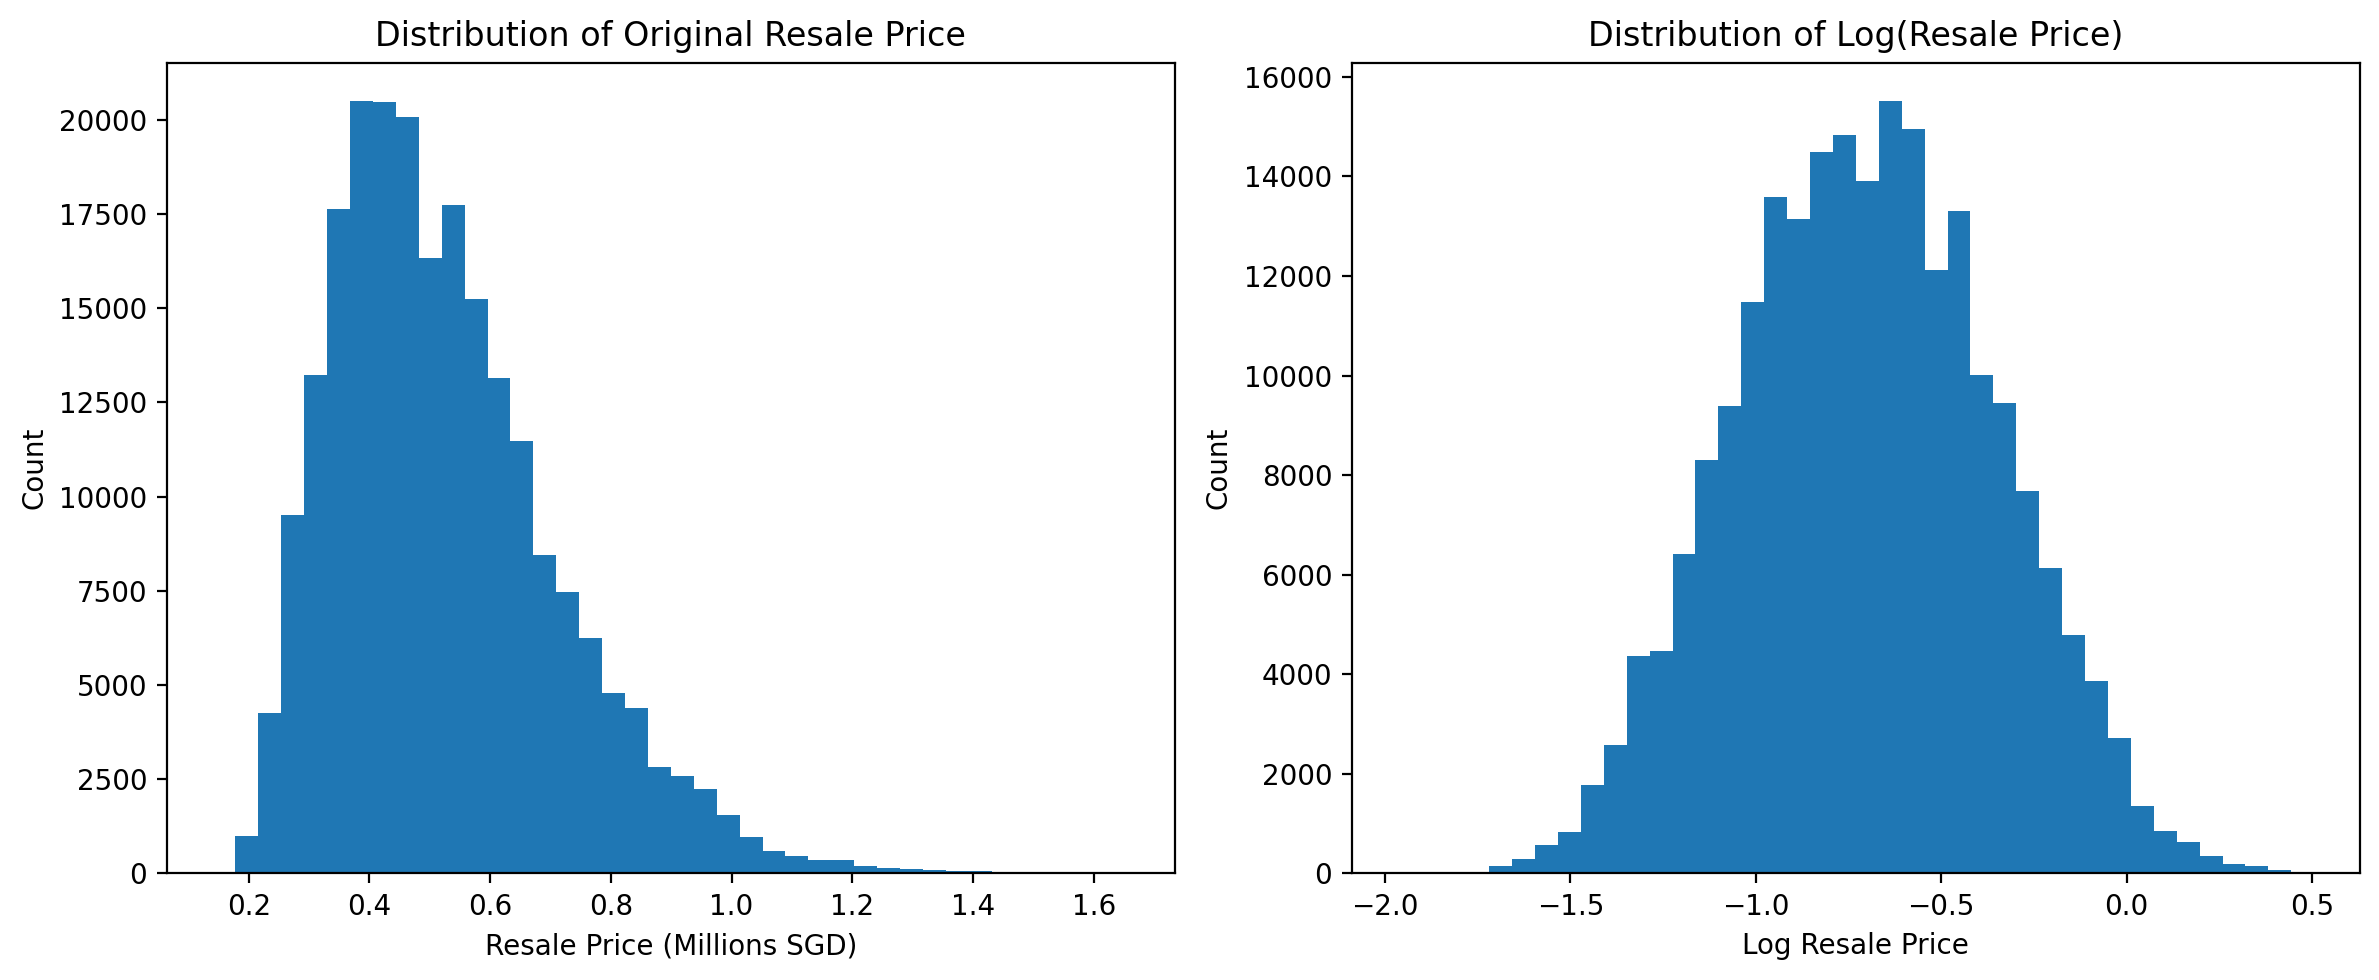

In [20]:
# Distribution + descriptive stats

def eda_target(df: pd.DataFrame):
    print("\n=== EDA 1: Target Summary ===")
    
    desc = df[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    desc = desc.map(lambda x: f"{x:,.0f}")
    print(desc)
    
    # Skewness
    original_skew = df[TARGET].skew()
    print("\nSkewness (original):", round(original_skew, 3))

    df["resale_price_mil"] = df["resale_price"] / 1e6
    
    # Histogram: Original resale price
    plt.figure(figsize=(12,5),dpi=200)

    plt.subplot(1,2,1)
    
    plt.hist(df["resale_price_mil"], bins=40)
    plt.title("Distribution of Original Resale Price")
    plt.xlabel("Resale Price (Millions SGD)")
    plt.ylabel("Count")

    # Log transformation
    df["log_resale_price"] = np.log(df["resale_price_mil"])
    log_skew = df["log_resale_price"].skew()
    print("Skewness (log):", round(log_skew, 3))
    print("")
    
    # Histogram: Log resale price
    plt.subplot(1,2,2)
    plt.hist(df["log_resale_price"], bins=40)
    plt.title("Distribution of Log(Resale Price)")
    plt.xlabel("Log Resale Price")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()
    
eda_target(df)

In [ ]:
# Observation: 

# The original resale price distribution is moderately right-skewed, while the log-transformed distribution is much more symmetric, indicating that log transformation may be appropriate for modeling.

## EDA 2: Structural Features vs Price

In [ ]:
# Scatter plots for numeric structural
# Group comparison for flat type (box plot of price)

def eda_structural(df: pd.DataFrame):
    print("\n=== EDA 2: Structural Features vs Price ===")

    # Scatterplot: numeric structural vs resale price
    for col in NUM_STRUCT_COLS:
        label = LABEL_MAP.get(col, col)

        # For storey level scatterplot
        if col == "storey_mid":
            tmp = (
                df[[col, "resale_price_mil"]]
                .dropna()
                .groupby(col, as_index=False)["resale_price_mil"]
                .mean()
            )

            plt.figure(figsize=(10,8), dpi=100)
            plt.plot(tmp[col], tmp["resale_price_mil"], marker="o")
            plt.title("Average Resale Price by Storey Level")
            plt.xlabel("Storey Level")
            plt.ylabel("Average Resale Price (Millions SGD)")
            plt.tight_layout()
            plt.show()

        # For floor area and remaining lease scatterplot
        else:
            sample = (
                df.dropna(subset=[col, "resale_price_mil"])
                  .groupby(df[DATE_COL].dt.year, group_keys=False)
                  .apply(lambda x: x.sample(frac=0.1, random_state=42))
            )
    
            plt.figure(figsize=(10,8), dpi=100)
            plt.scatter(sample[col], sample["resale_price_mil"], s=8, alpha=0.3)
            plt.title(f"Resale Price vs {label}")
            plt.xlabel(label)
            plt.ylabel("Resale Price (Millions SGD)")
            plt.tight_layout()
            plt.show()

    # Group comparison using box plot: flat type vs resale price
    fig, ax = plt.subplots(figsize=(10,8), dpi=100)
    tmp = df[[FLAT_TYPE_COL, "resale_price_mil"]].dropna()
    tmp.boxplot(column="resale_price_mil", by=FLAT_TYPE_COL, rot=45, ax=ax)
    ax.set_title("Resale Price by Flat Type")
    fig.suptitle("")
    ax.set_xlabel("Flat Type")
    ax.set_ylabel("Resale Price (Millions SGD)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
eda_structural(df)

In [ ]:
# Observations:

# Floor Area: Resale price generally increases with floor area, indicating that larger flats tend to command higher prices.

# Remaining Lease: Flats with longer remaining lease generally tend to have higher resale prices, although the relationship appears more dispersed than floor area.

# Storey Level: Average resale price increases with storey level, suggesting that higher-floor units tend to be priced at a premium.

# Flat Type: Median resale price rises consistently from smaller to larger flat types, indicating that bigger flat categories generally command higher prices.

## EDA 3: Spatial Accessibility vs Price

In [ ]:
# Scatter plots for distance features
# Binned plot (mean price by distance bin)

def eda_spatial(df: pd.DataFrame, n_bins: int = 10):
    print("\n=== EDA 3: Spatial Accessibility vs Price ===")

    for col in DIST_COLS:
        label = LABEL_MAP.get(col, col)
    
        sample = (
            df.dropna(subset=[col, "resale_price_mil"])
              .groupby(df[DATE_COL].dt.year, group_keys=False)
              .apply(lambda x: x.sample(frac=0.1, random_state=42))
        )

        # Scatterplot
        plt.figure(figsize=(10,8), dpi=100)
        plt.scatter(sample[col], sample["resale_price_mil"], s=8, alpha=0.3)
        plt.title(f"Resale Price vs {label}")
        plt.xlabel(label)
        plt.ylabel("Resale Price (Millions SGD)")
        plt.tight_layout()
        plt.show()

        # Binned mean (helps see non-linear / diminishing effects)
        tmp = df[[col, "resale_price_mil"]].copy()
        
        # Create quantile bins to balance counts per bin
        tmp["bin"] = pd.qcut(tmp[col], q=n_bins, duplicates="drop")
        grp = tmp.groupby("bin", observed=True)["resale_price_mil"].mean().reset_index()
        
        # Use bin midpoints for x-axis
        mids = tmp.groupby("bin", observed=True)[col].mean().values

        plt.figure(figsize=(10,8), dpi=100)
        plt.plot(mids, grp["resale_price_mil"].values, marker="o")
        plt.title(f"Average Resale Price by {label}")
        plt.xlabel(label)
        plt.ylabel("Average Resale Price (Millions SGD)")
        plt.tight_layout()
        plt.show()

eda_spatial(df)

In [ ]:
# Observations:

# Distance to MRT: Average resale price generally decreases as distance to the MRT increases, suggesting that flats closer to MRT stations tend to command a price premium.

# Distance to Mall: Average resale price generally declines as distance to malls increases, indicating that better access to malls is associated with higher resale values.

# Distance to School: The relationship between school distance and average resale price appears weak and inconsistent, suggesting that proximity to schools may not be a strong standalone driver of price.

# Distance to Hawker Centre: Average resale price shows a weak and noisy relationship with hawker centre distance, with only a slight tendency for prices to be lower at greater distances.

# Distance to SPF: The relationship between SPF distance and average resale price appears weak and non-monotonic, suggesting limited direct influence on resale prices.

## EDA 4: Town-level Variation

In [ ]:
# mean/median price by town

def eda_town(df: pd.DataFrame):
    print("\n=== EDA 4: Town-level Variation ===")

    tmp = df[[TOWN_COL, TARGET]]

    summary = (
        tmp.groupby(TOWN_COL)[TARGET]
        .agg(count="count", mean="mean", median="median")
        .sort_values("mean", ascending=True)
    )
    print(summary)

    # Horizontal bar plot: Average resale price by town
    plt.figure(figsize=(10,8), dpi=100)
    plt.barh(summary.index, summary["mean"].values)
    plt.title(f"Average Resale Price by Town")
    plt.xlabel("Average Resale Price (Millions SGD)")
    plt.ylabel("Town")
    plt.tight_layout()
    plt.show()
    
eda_town(df)

In [ ]:
# Observation: 

# Town-level differences in average resale prices are substantial, suggesting that locational factors play an important role in explaining resale price variation beyond structural flat characteristics alone.

## EDA 5: Time Trend

In [ ]:
# Average price over time (monthly)

def eda_time(df: pd.DataFrame):
    print("\n=== EDA 5: Time Trend and Market Conditions ===")

    tmp = df[[DATE_COL, TARGET, "RPI"]].dropna().copy()

    tmp[DATE_COL] = pd.to_datetime(tmp[DATE_COL], errors="coerce")
    tmp = tmp.dropna(subset=[DATE_COL])

    monthly = (
        tmp.groupby(pd.Grouper(key=DATE_COL, freq="MS"))
           .agg(
               mean_resale_price=(TARGET, "mean"),
               mean_rpi=("RPI", "mean")
           )
           .reset_index()
    )

    monthly["mean_resale_price_mil"] = monthly["mean_resale_price"] / 1e6
    
    fig, ax1 = plt.subplots(figsize=(10,6), dpi=100)

    line1, = ax1.plot(
        monthly[DATE_COL],
        monthly["mean_resale_price_mil"],
        label="Mean Resale Price",
        linewidth=2
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Average Resale Price (Millions SGD)")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    line2, = ax2.plot(
        monthly[DATE_COL],
        monthly["mean_rpi"],
        linestyle="--",
        linewidth=2,
        label="RPI"
    )
    ax2.set_ylabel("RPI")

    # combined legend
    lines = [line1, line2]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")
    plt.title("Monthly Average Resale Price and RPI Over Time")
    fig.tight_layout()
    plt.show()
    
eda_time(df)

In [ ]:
# Observation:

# Both average resale prices and RPI show a clear upward trend over time, suggesting that broader market conditions likely contributed to the rise in resale prices.

## EDA 6: Correlation Analysis

In [ ]:
# Correlation matrix for numeric predictors and target

def eda_correlation(df: pd.DataFrame):
    print("\n=== EDA 6: Correlation Matrix ===")

    cols = [TARGET] + NUM_STRUCT_COLS + DIST_COLS + ["RPI"]
    cols = [c for c in cols if c in df.columns]

    corr = df[cols].corr()
    display_labels = [LABEL_MAP.get(c, c) for c in cols]

    plt.figure(figsize=(10,8), dpi=100)

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        xticklabels=display_labels,
        yticklabels=display_labels,
        cmap="coolwarm"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
eda_correlation(df)

In [ ]:
# Observation:

# Structural features such as floor area, remaining lease, and storey level show stronger positive correlations with resale price than the distance variables, suggesting that structural characteristics may have a stronger linear relationship with resale price.

## EDA 7: Multicollinearity Assessment

In [ ]:
# variance inflation factor (VIF) for numeric predictors

def eda_vif(df: pd.DataFrame):
    print("\n=== EDA 7: Multicollinearity Assessment (VIF) ===")

    vif_cols = NUM_STRUCT_COLS + DIST_COLS + ["RPI"]
    vif_cols = [c for c in vif_cols if c in df.columns]

    X = df[vif_cols].dropna().copy()
    X = add_constant(X)

    vif_data = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    vif_data["VIF"] = vif_data["VIF"].round(3)
    vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)
    print(vif_data)

    # Exclude constant from VIF
    vif_plot = vif_data[vif_data["feature"] != "const"].copy()
    vif_plot = vif_plot.sort_values("VIF", ascending=False)
    vif_plot["label"] = vif_plot["feature"].map(lambda x: LABEL_MAP.get(x, x))
    
    plt.figure(figsize=(10, 8), dpi=100)
    plt.bar(vif_plot["label"], vif_plot["VIF"])
    plt.axhline(5, linestyle="--", label="VIF = 5")
    plt.axhline(10, linestyle="--", label="VIF = 10")
    plt.title("Variance Inflation Factor (VIF)")
    plt.xlabel("Numeric Predictor")
    plt.ylabel("VIF")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
eda_vif(df)

In [ ]:
# Observation:

# All predictors have VIF values close to 1 and well below common thresholds, suggesting that multicollinearity is not a concern among the selected numeric predictors.

In [30]:
# Feature columns to be used for modeling

keep_cols = [
    "date",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_months",
    "town",
    "flat_type",
    "flat_model",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI",
    "resale_price"
]

In [35]:
# Make a new copy of df with just the columns from keep_cols
df = df[keep_cols].copy()

## Modeling

In [36]:
target = "resale_price"

# flat_type excluded because floor_area_sqm already captures housing size, avoiding multicollinearity
feature_cols = [
    "floor_area_sqm", 
    "storey_mid", 
    "flat_type",
    "remaining_lease_months",
    "town", 
    "flat_model",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI"
]

data = df[["date"] + feature_cols + [target]].copy()

cutoff = pd.Timestamp("2024-12-31")

train = data[data["date"] <= cutoff]
test  = data[data["date"] > cutoff]

X_train = train[feature_cols]
y_train = train[target]

X_test  = test[feature_cols]
y_test  = test[target]

num_features = [
    "floor_area_sqm", 
    "storey_mid", 
    "remaining_lease_months",
    "dist_to_mrt_m",
    "dist_to_mall_m",
    "dist_to_school_m",
    "dist_to_hawker_m",
    "dist_to_spf_m",
    "RPI"
]

cat_features = ["town", "flat_type", "flat_model"]

# Preprocessing for one-hot encoding
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

## Cross-Validation

In [39]:
# Create a function for cv
def run_timeseries_cv(model, preprocess, X_train, y_train, n_splits=5, n_jobs=-1, log_y=False):
    
    # For modeling log(y)
    if log_y:
        model = TransformedTargetRegressor(regressor=model, func=np.log, inverse_func=np.exp)

    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    tscv = TimeSeriesSplit(n_splits=n_splits)

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

    # Perform cross-validation
    cv = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=n_jobs
    )

    # Convert scores for those negative values
    mae_scores = -cv["test_mae"]
    rmse_scores = -cv["test_rmse"]
    r2_scores = cv["test_r2"]

    # Build cv fold dataframe
    cv_df = pd.DataFrame({
        "Fold": range(1, len(mae_scores)+1),
        "MAE": mae_scores,
        "RMSE": rmse_scores,
        "R2": r2_scores
    })

    # Create mean row
    mean_row = pd.DataFrame({
        "Fold": ["Mean"],
        "MAE": [mae_scores.mean()],
        "RMSE": [rmse_scores.mean()],
        "R2": [r2_scores.mean()]
    })

    # Append mean row to cv fold dataframe
    cv_df = pd.concat([cv_df, mean_row], ignore_index=True)

    # Rounding
    cv_df = cv_df.round({"MAE":0, "RMSE":0, "R2":4})

    return cv_df

## Linear Regression

In [45]:
lr_cv = run_timeseries_cv(LinearRegression(), preprocess, X_train, y_train)
lr_cv

,Fold,MAE,RMSE,R2
0,1,40802.0,53405.0,0.8803
1,2,43048.0,57246.0,0.8700
2,3,42673.0,56127.0,0.8860
3,4,44712.0,60040.0,0.8793
4,5,49666.0,67832.0,0.8678
5,Mean,44180.0,58930.0,0.8767


## Linear Regression - log(y) 

In [41]:
lr_log_cv = run_timeseries_cv(LinearRegression(), preprocess, X_train, y_train, log_y=True)
lr_log_cv

,Fold,MAE,RMSE,R2
0,1,34986.0,48217.0,0.9024
1,2,35180.0,48911.0,0.9051
2,3,37553.0,51035.0,0.9058
3,4,38274.0,51390.0,0.9116
4,5,42434.0,69514.0,0.8611
5,Mean,37685.0,53813.0,0.8972


## Random Forest Regressor

In [79]:
model_rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
rf_cv = run_timeseries_cv(model_rf, preprocess, X_train, y_train)
rf_cv

,Fold,MAE,RMSE,R2
0,1,28672.0,41778.0,0.9267
1,2,31380.0,44333.0,0.9220
2,3,50349.0,64693.0,0.8486
3,4,40103.0,55015.0,0.8987
4,5,43707.0,60744.0,0.8940
5,Mean,38842.0,53313.0,0.8980


## Random Forest Regressor - log(y)

In [80]:
model_rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
rf_log_cv = run_timeseries_cv(model_rf, preprocess, X_train, y_train, log_y=True)
rf_log_cv

,Fold,MAE,RMSE,R2
0,1,29001.0,42969.0,0.9225
1,2,32834.0,47335.0,0.9111
2,3,51696.0,66756.0,0.8388
3,4,41275.0,56764.0,0.8921
4,5,44497.0,61638.0,0.8908
5,Mean,39860.0,55092.0,0.8911


## Random Forest Regressor (n_estimators=300)

In [52]:
model_rf_300 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_300_cv = run_timeseries_cv(model_rf_300, preprocess, X_train, y_train)
rf_300_cv

,Fold,MAE,RMSE,R2
0,1,26892.0,38828.0,0.9367
1,2,30335.0,43082.0,0.9264
2,3,49398.0,63071.0,0.8561
3,4,38980.0,53513.0,0.9041
4,5,42586.0,59380.0,0.8987
5,Mean,37638.0,51575.0,0.9044


## Random Forest Regressor (n_estimators=300) - log(y)

In [46]:
model_rf_300 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_300_log_cv = run_timeseries_cv(model_rf_300, preprocess, X_train, y_train, log_y=True)
rf_300_log_cv

,Fold,MAE,RMSE,R2
0,1,27215.0,40116.0,0.9324
1,2,31356.0,45280.0,0.9187
2,3,51145.0,65546.0,0.8446
3,4,40337.0,55348.0,0.8974
4,5,43630.0,60654.0,0.8943
5,Mean,38737.0,53389.0,0.8975


## Final Model Linear Regression

In [86]:
final_model_lr = LinearRegression()

final_pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_lr)
])

final_pipe_lr.fit(X_train, y_train)

pred_lr = final_pipe_lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = mean_squared_error(y_test, pred_lr, squared=False)
r2_lr   = r2_score(y_test, pred_lr)

print(f"Test MAE:  {mae_lr:,.0f}")
print(f"Test RMSE: {rmse_lr:,.0f}")
print(f"Test R2:   {r2_lr:.4f}")

Test MAE:  54,428
Test RMSE: 75,857
Test R2:   0.8618


## Final Model Linear Regression - log(y)

In [87]:
final_model_log_lr = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp
)

final_pipe_log_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_log_lr)
])

final_pipe_log_lr.fit(X_train, y_train)

pred_log_lr = final_pipe_log_lr.predict(X_test)

mae_log_lr  = mean_absolute_error(y_test, pred_log_lr)
rmse_log_lr = mean_squared_error(y_test, pred_log_lr, squared=False)
r2_log_lr   = r2_score(y_test, pred_log_lr)

print(f"Log-LR Test MAE:  {mae_log_lr:,.0f}")
print(f"Log-LR Test RMSE: {rmse_log_lr:,.0f}")
print(f"Log-LR Test R2:   {r2_log_lr:.4f}")

Log-LR Test MAE:  44,952
Log-LR Test RMSE: 60,124
Log-LR Test R2:   0.9132


## Final Model Random Forest Regressor

In [90]:
final_model_rf = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

final_pipe_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_rf)
])

final_pipe_rf.fit(X_train, y_train)

pred_rf = final_pipe_rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)
r2_rf   = r2_score(y_test, pred_rf)


print(f"RF Test MAE:  {mae_rf:,.0f}")
print(f"RF Test RMSE: {rmse_rf:,.0f}")
print(f"RF Test R2:   {r2_rf:.4f}")

RF Test MAE:  35,519
RF Test RMSE: 51,855
RF Test R2:   0.9354


## Final Model Random Forest Regressor - log(y)

In [91]:
final_model_log_rf = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

final_pipe_log_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_log_rf)
])

final_pipe_log_rf.fit(X_train, y_train)

pred_log_rf = final_pipe_log_rf.predict(X_test)

mae_log_rf  = mean_absolute_error(y_test, pred_log_rf)
rmse_log_rf = mean_squared_error(y_test, pred_log_rf, squared=False)
r2_log_rf   = r2_score(y_test, pred_log_rf)

print(f"Log-RF Test MAE:  {mae_log_rf:,.0f}")
print(f"Log-RF Test RMSE: {rmse_log_rf:,.0f}")
print(f"Log-RF Test R2:   {r2_log_rf:.4f}")

Log-RF Test MAE:  36,544
Log-RF Test RMSE: 53,698
Log-RF Test R2:   0.9308


## Final Models

In [92]:
final_test_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log Linear Regression",
        "Random Forest",
        "Log Random Forest"
    ],
    "MAE": [mae_lr, mae_log_lr, mae_rf, mae_log_rf],
    "RMSE": [rmse_lr, rmse_log_lr, rmse_rf, rmse_log_rf],
    "R2": [r2_lr, r2_log_lr, r2_rf, r2_log_rf]
}).round({"MAE": 0, "RMSE": 0, "R2": 4})

final_test_df

,Model,MAE,RMSE,R2
0,Linear Regression,54413.0,75853.0,0.8619
1,Log Linear Regression,44960.0,60119.0,0.9132
2,Random Forest,35519.0,51855.0,0.9354
3,Log Random Forest,36544.0,53698.0,0.9308


## Final Model Random Forest Regressor (n_estimators=300)

In [82]:
final_model_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_pipe_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_rf)
])

final_pipe_rf.fit(X_train, y_train)

pred_rf = final_pipe_rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)
r2_rf   = r2_score(y_test, pred_rf)


print(f"RF Test MAE:  {mae_rf:,.0f}")
print(f"RF Test RMSE: {rmse_rf:,.0f}")
print(f"RF Test R2:   {r2_rf:.4f}")

RF Test MAE:  34,114
RF Test RMSE: 49,791
RF Test R2:   0.9405


## Final Model Random Forest Regressor (n_estimators=300) - log(y)

In [84]:
final_model_log_rf = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    func=np.log,
    inverse_func=np.exp
)

final_pipe_log_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", final_model_log_rf)
])

final_pipe_log_rf.fit(X_train, y_train)

pred_log_rf = final_pipe_log_rf.predict(X_test)

mae_log_rf  = mean_absolute_error(y_test, pred_log_rf)
rmse_log_rf = mean_squared_error(y_test, pred_log_rf, squared=False)
r2_log_rf   = r2_score(y_test, pred_log_rf)

print(f"Log-RF Test MAE:  {mae_log_rf:,.0f}")
print(f"Log-RF Test RMSE: {rmse_log_rf:,.0f}")
print(f"Log-RF Test R2:   {r2_log_rf:.4f}")

Log-RF Test MAE:  35,165
Log-RF Test RMSE: 51,822
Log-RF Test R2:   0.9355


## Final Models

In [89]:
final_test_df

,Model,MAE,RMSE,R2
0,Linear Regression,54428.0,75857.0,0.8618
1,Log Linear Regression,44952.0,60124.0,0.9132
2,Random Forest,34114.0,49791.0,0.9405
3,Log Random Forest,35165.0,51822.0,0.9355


## Feature Importances

In [124]:
rf = final_pipe_rf.named_steps["model"]
feature_names = final_pipe_rf.named_steps["prep"].get_feature_names_out()

imp = pd.Series(
    rf.feature_importances_, 
    index=feature_names
).sort_values(ascending=False)

imp.head(20)

num__floor_area_sqm            0.397216
num__RPI                       0.147056
num__storey_mid                0.093482
num__remaining_lease_months    0.068817
num__dist_to_mrt_m             0.027405
num__dist_to_spf_m             0.023348
cat__town_BUKIT MERAH          0.022589
cat__town_QUEENSTOWN           0.021754
num__dist_to_hawker_m          0.019517
cat__flat_model_DBSS           0.018964
cat__town_BISHAN               0.015641
cat__flat_type_4 ROOM          0.013347
num__dist_to_school_m          0.012005
num__dist_to_mall_m            0.011868
cat__town_CENTRAL AREA         0.008737
cat__flat_type_2 ROOM          0.007557
cat__town_WOODLANDS            0.007528
cat__town_TOA PAYOH            0.007516
cat__town_KALLANG/WHAMPOA      0.007415
cat__town_CLEMENTI             0.005389
dtype: float64